# STG and LSPIN Evaluation Notebook

This notebook runs the iterative feature-reduction experiment across the six loaded datasets:
- Breast, defined as "hard" dataset
- madelon, defined as "hard" dataset
- SMK-CAN-187, defined as "medium" dataset
- colon, defined as "medium" dataset
- leukemia, defined as "easy" dataset
- RELATHE, defined as "easy" dataset

## Workflow
1. Initialize notebook environment.
2. Configure paths and load datasets.
3. Apply reproducibility settings (seeding).
4. Run STG/LSPIN feature selection + ExtraTrees evaluation in 5-fold CV.
5. Plot and save train/test curves.
6. Write outputs into a dedicated output folder.
7. Re-run safety checks for repeatability.

## Initialize Imports, Libraries, and Global Configuration

In [13]:
%pip install featselectlib lifelines tabicl

In [14]:
from __future__ import annotations
import collections as _collections
import os
import random
from pathlib import Path
from typing import Any, Dict, Mapping, MutableMapping, Sequence, Tuple
from collections import abc as _collections_abc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import sparse as sp
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

for _alias in ("Callable", "Iterable", "Mapping", "MutableMapping", "Sequence", "Set"):
    if not hasattr(_collections, _alias):
        setattr(_collections, _alias, getattr(_collections_abc, _alias))

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive", force_remount=False)

PROJECT_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/Colab Notebooks/Thesis"),
    Path.cwd(),
]
BASE_DIR = next((p for p in PROJECT_DIR_CANDIDATES if p.exists()), Path.cwd())
os.chdir(BASE_DIR)

try:
    from featselectlib.supervised_feature_selection.Lspin import DataSetMeta, Lspin
    from featselectlib.supervised_feature_selection.stg.python.stg import STG
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency 'featselectlib'. Install it first (for example in Colab: !pip install featselectlib)."
    ) from exc

OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
date_and_time = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
OUTPUT_DIR = OUTPUT_DIR / date_and_time


SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Torch device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Google Colab
Base directory: /content/drive/MyDrive/Colab Notebooks/Thesis
Output directory: /content/drive/MyDrive/Colab Notebooks/Thesis/output/2026-04-25_21-07-05
Torch device: cuda
GPU: Tesla T4


In [ ]:
# ==============================================================================
# GLOBAL EXPERIMENT CONFIGURATION
# ==============================================================================
# 1. Select the evaluation method.
# Options: "features_ratio", "lamda_tuning"
feature_selection_method = "lamda_tuning"

# Select downstream prediction model
# Options: 'etree', 'tabiclv2'
prediction_model_type = 'tabiclv2'

OUTPUT_DIR = BASE_DIR / "output" / "2026-04-22_21-15-37"
print(f"Output directory: {OUTPUT_DIR}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. Select which datasets you want to evaluate.
DEFAULT_DATASET_NAMES = [ "madelon"]  # Hard/easy datasets combinations "madelon",

# 3. Features ratio configuration (only used if "features_ratio" is selected)

# Ratios evaluated: 100%, 90%, ..., 10%, 5%
feature_ratios = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05]

# 4. Lambda tuning configuration (only used if "lamda_tuning" is selected)
# Default fallback sequence for datasets without specific ranges
lambda_values = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

# Paired STG/LSPIN lambda ranges per dataset (using geomspace to distribute points log-linearly)
lambda_ranges_by_dataset = {
    "madelon": {
        "stg": np.geomspace(0.9, 3, num=7).tolist(),
        "lspin": np.geomspace(0.01, 10, num=7).tolist(),
    },
    "RELATHE": {
        "stg": np.geomspace(10, 17, num=7).tolist(),
        "lspin": np.geomspace(0.03, 200, num=7).tolist(),
    },
}

if feature_selection_method == "features_ratio":
    print("Feature selection method: features_ratio")
else:
    print("Feature selection method: lamda_tuning")
    print(f"Dataset-specific lambda ranges mapped: {list(lambda_ranges_by_dataset.keys())}")
    print(f"lambda ranges for datasets without specific mapping: {lambda_ranges_by_dataset}")


Output directory: /content/drive/MyDrive/Colab Notebooks/Thesis/output/2026-04-24_14-32-29
Feature selection method: lamda_tuning
Dataset-specific lambda ranges mapped: ['madelon', 'RELATHE']
lambda ranges for datasets without specific mapping: {'madelon': {'stg': [0.9, 1.0999905824917022, 1.3444214239671495, 1.6431676725154982, 2.0082988502465082, 2.4545664690000804, 3.0], 'lspin': [0.01, 0.03162277660168379, 0.1, 0.31622776601683794, 1.0, 3.1622776601683795, 10.0]}, 'RELATHE': {'stg': [10.0, 10.924665632994616, 11.934831919273368, 13.0384048104053, 14.244021294130647, 15.561116990763258, 17.0], 'lspin': [0.03, 0.1301485632646727, 0.564621617328617, 2.4494897427831774, 10.626585691826111, 46.101162006669895, 200.0]}}


## Dataset Paths from Local Data Folder

This section resolves dataset paths for both local runs and Google Colab/Drive runs, reports which required datasets exist, and loads available `.mat` files into memory.

In [16]:
data_root_candidates = [
    BASE_DIR / "data",
    Path(r"c:/Users/shlom/Thesis/data"),
    Path("/content/drive/MyDrive/Colab Notebooks/Thesis/data"),
    Path("/content/drive/Othercomputers/המחשב האישי שלי/Thesis/data"),
]
DATA_ROOT = next((p for p in data_root_candidates if p.exists()), data_root_candidates[0])
print(f"Data root: {DATA_ROOT}")
DATASET_PATHS = {
    "Breast": DATA_ROOT / "Challenging Data Collections" / "Unaltered Data Sources" / "Breast.mat",
    "madelon": DATA_ROOT / "Challenging Data Collections" / "Unaltered Data Sources" / "madelon.mat",
    "SMK-CAN-187": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "SMK-CAN-187.mat",
    "colon": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "colon.mat",
    "leukemia": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "leukemia.mat",
    "RELATHE": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" / "RELATHE.mat",
}

path_status_df = pd.DataFrame(
    [{"dataset": name, "path": str(path), "exists": path.exists()} for name, path in DATASET_PATHS.items()]
)
display(path_status_df)

Data root: /content/drive/MyDrive/Colab Notebooks/Thesis/data


,dataset,path,exists
0,Breast,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
1,madelon,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
2,SMK-CAN-187,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
3,colon,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
4,leukemia,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
5,RELATHE,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True


## Check and Report Dataset File Paths

In [17]:
from scipy.io import loadmat


def _load_mat_xy(mat_path: Path) -> tuple[np.ndarray, np.ndarray]:
    mat = loadmat(mat_path)

    feature_keys = ("X", "x", "data", "features", "fea")
    label_keys = ("y", "Y", "labels", "label", "target", "gnd")

    X = next((mat[k] for k in feature_keys if k in mat), None)
    y = next((mat[k] for k in label_keys if k in mat), None)

    if X is None or y is None:
        raise KeyError(f"Could not find feature/label keys in {mat_path.name}")

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)
    return X, y


def _load_dataset_xy(path: Path) -> tuple[np.ndarray, np.ndarray]:
    if path.suffix.lower() != ".mat":
        raise ValueError(f"Unsupported dataset format: {path.name}. Only .mat files are supported.")
    return _load_mat_xy(path)


loaded_from_data_folder = {}
missing_from_data_folder = []

for dataset_name, dataset_path in DATASET_PATHS.items():
    if dataset_path.exists():
        X, y = _load_dataset_xy(dataset_path)
        globals()[dataset_name] = (X, y)
        loaded_from_data_folder[dataset_name] = {"shape": X.shape, "labels": np.unique(y).size}
    else:
        missing_from_data_folder.append(dataset_name)

print("Loaded datasets from data folder:")
for name, meta in loaded_from_data_folder.items():
    print(f"- {name}: X shape={meta['shape']}, #classes={meta['labels']}")

if missing_from_data_folder:
    print("\nMissing datasets in data folder:", ", ".join(missing_from_data_folder))

Loaded datasets from data folder:
- Breast: X shape=(97, 24481), #classes=2
- madelon: X shape=(2600, 500), #classes=2
- SMK-CAN-187: X shape=(187, 19993), #classes=2
- colon: X shape=(62, 2000), #classes=2
- leukemia: X shape=(72, 7070), #classes=2
- RELATHE: X shape=(1427, 4322), #classes=2


## Define Functions to Load .mat File Format

In [18]:
def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)
print("Global seed configured:", SEED)

Global seed configured: 42


## Define Feature Selection and Evaluation Pipeline
The following cells define modular functions for baseline ExtraTrees, STG, and LSPIN with 5-fold CV across iterative feature ratios: 100%, 90%, 80%, ..., 10%, and 5%.

In [19]:
def _as_numpy_array(value: Any) -> np.ndarray:
    if sp.issparse(value):
        return value.toarray()
    if hasattr(value, "to_numpy"):
        return value.to_numpy()
    return np.asarray(value)


def extract_xy(dataset: Any) -> Tuple[np.ndarray, np.ndarray]:
    if isinstance(dataset, (tuple, list)):
        if len(dataset) != 2:
            raise ValueError("Dataset tuple/list must have exactly (X, y).")
        return _as_numpy_array(dataset[0]), np.asarray(dataset[1])

    if isinstance(dataset, Mapping):
        feature_keys = ("X", "x", "data", "features")
        label_keys = ("y", "Y", "labels", "target", "targets")
        X = next((dataset[k] for k in feature_keys if k in dataset), None)
        y = next((dataset[k] for k in label_keys if k in dataset), None)
        if X is None or y is None:
            raise ValueError("Dataset mapping must include feature and label entries.")
        return _as_numpy_array(X), np.asarray(y)

    for feature_attr, label_attr in (("data", "target"), ("X", "y"), ("features", "labels")):
        if hasattr(dataset, feature_attr) and hasattr(dataset, label_attr):
            return _as_numpy_array(getattr(dataset, feature_attr)), np.asarray(getattr(dataset, label_attr))

    raise TypeError("Unsupported dataset format.")


def encode_labels(y: np.ndarray) -> Tuple[np.ndarray, LabelEncoder]:
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(np.asarray(y).ravel())
    return y_encoded, encoder


def prepare_fold_arrays(X_train: np.ndarray, X_test: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    scaler = StandardScaler(with_mean=not sp.issparse(X_train))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if sp.issparse(X_train_scaled):
        X_train_scaled = X_train_scaled.toarray()
    if sp.issparse(X_test_scaled):
        X_test_scaled = X_test_scaled.toarray()

    return np.asarray(X_train_scaled, dtype=np.float32), np.asarray(X_test_scaled, dtype=np.float32)


def compute_auc(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    if y_proba.ndim == 1 or y_proba.shape[1] == 1:
        return float(roc_auc_score(y_true, y_proba.ravel()))
    if y_proba.shape[1] == 2:
        return float(roc_auc_score(y_true, y_proba[:, 1]))
    return float(roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"))


def fit_extra_trees(
    X_train: np.ndarray,
    y_train: np.ndarray,
    random_state: int,
    n_estimators: int = 200,
    max_depth: int | None = 4,
    min_samples_leaf: int = 1,
    max_features: str | float | int | None = "sqrt",
) -> ExtraTreesClassifier:
    clf = ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    return clf


def evaluate_classifier(clf, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    return {
        "auc": compute_auc(y_test, y_proba),
        "accuracy": float(accuracy_score(y_test, y_pred)),
    }


def build_feature_ratios() -> list[float]:
    ratios = [1.0] + [round(v, 2) for v in np.arange(0.9, 0.0, -0.1)] + [0.05]
    return sorted(set(ratios), reverse=True)


def build_lambda_grid(lower: float, upper: float, num_values: int = 5) -> list[float]:
    if num_values < 2:
        return [float(lower)]
    return [float(value) for value in np.geomspace(float(lower), float(upper), num=num_values)]


def ratio_to_k(p: int, ratio: float) -> int:
    return max(1, int(round(ratio * p)))


def get_checkpoint_path(dataset_name: str) -> Path:
    return OUTPUT_DIR / f"checkpoint_{dataset_name}.pkl"


def load_checkpoint(dataset_name: str) -> pd.DataFrame:
    checkpoint_path = get_checkpoint_path(dataset_name)
    if checkpoint_path.exists():
        return pd.read_pickle(checkpoint_path)
    return pd.DataFrame()


def save_checkpoint(dataset_name: str, fold_df: pd.DataFrame) -> None:
    checkpoint_path = get_checkpoint_path(dataset_name)
    fold_df.to_pickle(checkpoint_path)


def collect_loaded_datasets(namespace: MutableMapping[str, Any] | None = None, allow_partial: bool = True) -> Dict[str, Any]:
    namespace = globals() if namespace is None else namespace
    available = {name: namespace[name] for name in DEFAULT_DATASET_NAMES if name in namespace}
    missing = [name for name in DEFAULT_DATASET_NAMES if name not in namespace]

    if missing and not allow_partial:
        raise KeyError(f"Missing dataset variables: {', '.join(missing)}")

    if missing:
        print("Skipping missing datasets:", ", ".join(missing))
    return available

In [20]:
LAMBDA_SEQUENCE_DEFAULT = (0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0)


def build_lambda_sequence(
    initial_lam: float = 0.1,
    multipliers: Sequence[float] = (5.0, 2.0, 5.0, 2.0, 5.0, 2.0),
) -> list[float]:
    values = [float(initial_lam)]
    current = float(initial_lam)
    for multiplier in multipliers:
        current *= float(multiplier)
        values.append(float(current))
    return values


def _select_from_scores(
    scores: np.ndarray,
    feature_selection_method: str,
    k: int | None,
) -> tuple[np.ndarray, int]:
    scores = np.asarray(scores, dtype=np.float32).reshape(-1)
    active_indices = np.where(scores > 0)[0]
    active_count = int(active_indices.size)

    if feature_selection_method == "features_ratio":
        if k is None:
            raise ValueError("k must be provided when feature_selection_method='features_ratio'.")
        selected_indices = np.argsort(scores)[-k:][::-1]
        return selected_indices, active_count

    if feature_selection_method == "lamda_tuning":
        if active_count > 0:
            return active_indices, active_count
        fallback = np.array([int(np.argmax(scores))], dtype=np.int64)
        return fallback, 0

    raise ValueError(f"Unknown feature_selection_method: {feature_selection_method}")


def _effective_lspin_batch_size(n_samples: int, requested_batch_size: int, batch_normalization: bool) -> int:
    if requested_batch_size <= 0:
        requested_batch_size = n_samples

    batch_size = int(min(requested_batch_size, n_samples))
    if not batch_normalization:
        return max(1, batch_size)

    if n_samples <= 1:
        return 1

    if batch_size <= 1:
        return 2

    # Avoid a final mini-batch of exactly one sample when batch norm is on.
    if n_samples % batch_size == 1:
        for candidate in range(batch_size + 1, n_samples + 1):
            if n_samples % candidate != 1:
                return candidate
    return batch_size


def fit_stg_selector(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int | None,
    random_state: int,
    feature_selection_method: str = "features_ratio",
    epochs: int = 50,
    learning_rate: float = 1e-4,
    hidden_dims: Sequence[int] = (128, 64),
    sigma: float = 0.5,
    lam: float = 0.1,
    batch_size: int = 64,
    optimizer: str = "SGD",
    activation: str = "tanh",
    early_stopping_patience: int = 25,
    early_stopping_min_delta: float = 1e-4,
    early_stopping_min_epochs: int = 50,
) -> Tuple[np.ndarray, list[float], int]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    selector = STG(
        device=device,
        input_dim=n_features,
        output_dim=n_classes,
        hidden_dims=list(hidden_dims),
        activation=activation,
        sigma=sigma,
        lam=lam,
        optimizer=optimizer,
        learning_rate=learning_rate,
        batch_size=batch_size,
        task_type="classification",
        random_state=random_state,
    )

    train_loader = selector.get_dataloader(X_train, y_train, shuffle=True)
    train_losses = []
    best_loss = float("inf")
    bad_epochs = 0

    for epoch_index in range(epochs):
        epoch_meters = selector.train_epoch(train_loader)
        epoch_loss = None
        if hasattr(epoch_meters, "avg") and epoch_meters.avg is not None:
            epoch_loss = epoch_meters.avg.get("loss")

        if epoch_loss is None:
            continue

        current_loss = float(epoch_loss)
        train_losses.append(current_loss)
        if current_loss < best_loss - early_stopping_min_delta:
            best_loss = current_loss
            bad_epochs = 0
        else:
            bad_epochs += 1

        if (epoch_index + 1) >= early_stopping_min_epochs and bad_epochs >= early_stopping_patience:
            print(f"STG early stopping at epoch {epoch_index + 1} (best loss={best_loss:.6f})")
            break

    gate_values = selector.get_gates("prob")
    if isinstance(gate_values, torch.Tensor):
        gate_values = gate_values.detach().cpu().numpy()
        
    gate_array = np.asarray(gate_values, dtype=np.float32).flatten()
    
    # Global STG gate extraction & active count
    active_count = int(np.sum(gate_array > 0))
    
    selected_indices, _ = _select_from_scores(gate_array, feature_selection_method, k)
    return selected_indices, train_losses, active_count


def fit_lspin_selector(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int | None,
    random_state: int,
    feature_selection_method: str = "features_ratio",
    epochs: int = 50,
    learning_rate: float = 0.1,
    hidden_layers: Sequence[int] = (128, 64),
    gating_hidden_layers: Sequence[int] = (64,),
    sigma: float = 0.5,
    lam: float = 0.5,
    batch_size: int = 64,
    batch_normalization: bool = True,
    activation_gating: str = "tanh",
    activation_pred: str = "tanh",
    optimizer: str = "SGD",
    early_stopping_patience: int = 25,
    early_stopping_min_delta: float = 1e-4,
    early_stopping_min_epochs: int = 50,
    **_: Any,
) -> Tuple[np.ndarray, list[float], float, Any]:
    n_features = X_train.shape[1]
    labels = np.asarray(y_train).ravel()
    classes = np.unique(labels)
    class_to_index = {label: idx for idx, label in enumerate(classes)}
    y_index = np.array([class_to_index[label] for label in labels], dtype=np.int64)
    y_one_hot = np.eye(len(classes), dtype=np.float32)[y_index]
    metadata = np.zeros((X_train.shape[0], 1), dtype=np.float32)

    train_dataset = DataSetMeta(np.asarray(X_train, dtype=np.float32), y_one_hot, metadata)
    model = Lspin(
        input_node=n_features,
        hidden_layers_node=list(hidden_layers),
        output_node=len(classes),
        gating_net_hidden_layers_node=list(gating_hidden_layers),
        display_step=epochs + 1,
        activation_gating=activation_gating,
        activation_pred=activation_pred,
        feature_selection=True,
        batch_normalization=batch_normalization,
        sigma=sigma,
        lam=lam,
        seed=random_state,
        val=False,
    )

    train_losses = []
    best_loss = float("inf")
    bad_epochs = 0
    effective_batch_size = _effective_lspin_batch_size(X_train.shape[0], int(batch_size), bool(batch_normalization))

    for epoch_index in range(epochs):
        epoch_losses, _, _ = model.train_model(
            train_dataset,
            batch_size=effective_batch_size,
            num_epoch=1,
            lr=learning_rate,
            compute_sim=False,
        )
        epoch_loss = epoch_losses[-1] if epoch_losses else None
        if epoch_loss is None:
            continue

        current_loss = float(epoch_loss)
        train_losses.append(current_loss)
        if current_loss < best_loss - early_stopping_min_delta:
            best_loss = current_loss
            bad_epochs = 0
        else:
            bad_epochs += 1

        if (epoch_index + 1) >= early_stopping_min_epochs and bad_epochs >= early_stopping_patience:
            print(f"LSPIN early stopping at epoch {epoch_index + 1} (best loss={best_loss:.6f})")
            break

    gate_matrix = model.get_prob_alpha(torch.as_tensor(X_train, dtype=torch.float32, device=model.device))
    if isinstance(gate_matrix, torch.Tensor):
        gate_matrix = gate_matrix.detach().cpu().numpy()
        
    # Get the global score proxy for indice selection
    if gate_matrix.ndim == 1:
        global_scores = gate_matrix.reshape(-1)
        gate_matrix_2d = gate_matrix.reshape(1, -1)
    else:
        global_scores = gate_matrix.mean(axis=0)
        gate_matrix_2d = gate_matrix

    # Compute actual local active counts strictly > 0 per sample, then take the average
    active_counts_per_sample = np.sum(gate_matrix_2d > 0, axis=1)
    average_active_count = float(np.mean(active_counts_per_sample))

    selected_indices, _ = _select_from_scores(global_scores, feature_selection_method, k)
    return selected_indices, [float(value) for value in train_losses], average_active_count, model

def expand_loss_histories(fold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for row in fold_df.itertuples(index=False):
        common = {
            "dataset": row.dataset,
            "fold": int(row.fold),
            "feature_selection_method": getattr(row, "feature_selection_method", "features_ratio"),
            # Keep selection key as text for paired lambda tuning (e.g., "stg=1|lspin=10")
            "selection_value": str(getattr(row, "selection_value", "")),
            "stg_feature_ratio": float(getattr(row, "stg_feature_ratio", np.nan)),
            "lspin_feature_ratio": float(getattr(row, "lspin_feature_ratio", np.nan)),
            "lambda_value": float(getattr(row, "lambda_value", np.nan)),
            "lspin_lambda_value": float(getattr(row, "lspin_lambda_value", np.nan)),
        }

        stg_losses = list(getattr(row, "stg_train_loss_history", []) or [])
        lspin_losses = list(getattr(row, "lspin_train_loss_history", []) or [])

        for epoch_index, loss_value in enumerate(stg_losses, start=1):
            rows.append({**common, "algorithm": "STG", "epoch": epoch_index, "train_loss": float(loss_value)})
        for epoch_index, loss_value in enumerate(lspin_losses, start=1):
            rows.append({**common, "algorithm": "LSPIN", "epoch": epoch_index, "train_loss": float(loss_value)})

    return pd.DataFrame(rows)

In [21]:
def checkpoint_key(dataset_name: str, feature_selection_method: str, selection_value: str, fold_index: int) -> str:
    return f"{dataset_name}|{feature_selection_method}|{selection_value}|{fold_index}"


def summarize_fold_results(fold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = [
        "dataset",
        "feature_selection_method",
        "selection_value",
        "lambda_value",
        "lspin_lambda_value",
        "p",
    ]

    for keys, part in fold_df.groupby(group_cols, dropna=False):
        (
            dataset_name,
            feature_selection_method,
            selection_value,
            lambda_value,
            lspin_lambda_value,
            p,
        ) = keys

        stg_k_mean = part["stg_k"].mean() if "stg_k" in part.columns else np.nan
        stg_k_value = int(round(float(stg_k_mean))) if pd.notna(stg_k_mean) else np.nan
        stg_feature_ratio_value = float(stg_k_value / int(p)) if pd.notna(stg_k_value) and int(p) > 0 else np.nan

        lspin_k_mean = part["lspin_k"].mean() if "lspin_k" in part.columns else np.nan
        lspin_k_value = int(round(float(lspin_k_mean))) if pd.notna(lspin_k_mean) else np.nan
        lspin_feature_ratio_value = float(lspin_k_value / int(p)) if pd.notna(lspin_k_value) and int(p) > 0 else np.nan

        rows.append(
            {
                "dataset": dataset_name,
                "feature_selection_method": feature_selection_method,
                "selection_value": selection_value,
                "stg_feature_ratio": stg_feature_ratio_value,
                "lspin_feature_ratio": lspin_feature_ratio_value,
                "lambda_value": float(lambda_value) if pd.notna(lambda_value) else np.nan,
                "lspin_lambda_value": float(lspin_lambda_value) if pd.notna(lspin_lambda_value) else np.nan,
                "p": int(p),
                "stg_k": stg_k_value,
                "lspin_k": lspin_k_value,
                "stg_selected_features_mean": part["stg_selected_features"].mean(),
                "lspin_selected_features_mean": part["lspin_selected_features"].mean(),
                "baseline_train_auc_mean": part["baseline_train_auc"].mean(),
                "stg_train_auc_mean": part["stg_train_auc"].mean(),
                "lspin_train_auc_mean": part["lspin_train_auc"].mean(),
                "baseline_auc_mean": part["baseline_auc"].mean(),
                "stg_auc_mean": part["stg_auc"].mean(),
                "lspin_auc_mean": part["lspin_auc"].mean(),
                "stg_auc_delta_mean": part["stg_auc_delta"].mean(),
                "lspin_auc_delta_mean": part["lspin_auc_delta"].mean(),
                "baseline_train_accuracy_mean": part["baseline_train_accuracy"].mean(),
                "stg_train_accuracy_mean": part["stg_train_accuracy"].mean(),
                "lspin_train_accuracy_mean": part["lspin_train_accuracy"].mean(),
                "baseline_accuracy_mean": part["baseline_accuracy"].mean(),
                "stg_accuracy_mean": part["stg_accuracy"].mean(),
                "lspin_accuracy_mean": part["lspin_accuracy"].mean(),
                "stg_accuracy_delta_mean": part["stg_accuracy_delta"].mean(),
                "lspin_accuracy_delta_mean": part["lspin_accuracy_delta"].mean(),
            }
        )

    sort_cols = ["dataset", "feature_selection_method", "selection_value"]
    return pd.DataFrame(rows).sort_values(sort_cols).reset_index(drop=True)


def fit_prediction_model(X_train: np.ndarray, y_train: np.ndarray, prediction_model_type: str, random_state: int, etree_params: Mapping[str, Any]):
    if prediction_model_type == 'etree':
        etree_params_local = dict(etree_params)
        # Apply the requested default values if not explicitly provided
        etree_params_local.setdefault('n_estimators', 200)
        etree_params_local.setdefault('max_depth', 4)
        return fit_extra_trees(X_train, y_train, random_state=random_state, **etree_params_local)
    elif prediction_model_type == 'tabiclv2':
        try:
            from tabicl import TabICLClassifier
        except ImportError:
            raise ImportError("tabicl is not installed. Please install it to use the 'tabiclv2' prediction model type.")
        
        # Create classifier; can use kv_cache=True for faster repeated calls on same training data if desired
        model = TabICLClassifier(
            # disk_offload_dir=str(BASE_DIR / "tabicl_cache"),
                                  kv_cache=False,
                                 random_state=random_state,
                                #  batch_size=256,
                                 device=DEVICE,
                                 model_path=OUTPUT_DIR / "tabiclv2_model",
                                 verbose=True,
                                 )
        model.fit(X_train, y_train)
        return model
    else:
        raise ValueError(f"Unknown prediction_model_type: {prediction_model_type}")


def run_fold_experiment(
    dataset_name: str,
    fold_index: int,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    random_state: int,
    stg_params: Mapping[str, Any],
    lspin_params: Mapping[str, Any],
    etree_params: Mapping[str, Any],
    feature_selection_method: str,
    selection_value: Any,
    k: int | None = None,
    ratio: float | None = None,
    lambda_value: float | None = None,
    lspin_lambda_value: float | None = None,
    run_stg: bool = True,
    run_lspin: bool = True,
    prediction_model_type: str = 'etree',
) -> Dict[str, Any]:
    X_train_scaled, X_test_scaled = prepare_fold_arrays(X_train, X_test)

    baseline_model = fit_prediction_model(X_train_scaled, y_train, prediction_model_type, random_state, etree_params)
    baseline_train_metrics = evaluate_classifier(baseline_model, X_train_scaled, y_train)
    baseline_metrics = evaluate_classifier(baseline_model, X_test_scaled, y_test)

    stg_cfg = dict(stg_params)
    lspin_cfg = dict(lspin_params)

    if feature_selection_method == "lamda_tuning":
        if lambda_value is None:
            raise ValueError("lambda_value is required when feature_selection_method='lamda_tuning'.")
        stg_cfg["lam"] = float(lambda_value)
        lspin_cfg["lam"] = float(lspin_lambda_value if lspin_lambda_value is not None else lambda_value)

    if lspin_cfg.get("batch_size", 64) == -1:
        lspin_cfg["batch_size"] = X_train_scaled.shape[0]

    if run_stg:
        stg_features, stg_train_loss_history, stg_active_count = fit_stg_selector(
            X_train_scaled,
            y_train,
            k=k,
            random_state=random_state,
            feature_selection_method=feature_selection_method,
            **stg_cfg,
        )
        # Fallback to at least one feature if perfectly pruned to avoid ExtraTrees crash
        if len(stg_features) == 0:
            stg_features = [0]
            stg_active_count = 0.0 # Keep recorded metrics accurate
            
        stg_model = fit_prediction_model(X_train_scaled[:, stg_features], y_train, prediction_model_type, random_state, etree_params)
        stg_train_metrics = evaluate_classifier(stg_model, X_train_scaled[:, stg_features], y_train)
        stg_metrics = evaluate_classifier(stg_model, X_test_scaled[:, stg_features], y_test)
    else:
        stg_features, stg_train_loss_history, stg_active_count = [], [], 0
        stg_train_metrics = {"auc": np.nan, "accuracy": np.nan}
        stg_metrics = {"auc": np.nan, "accuracy": np.nan}

    if run_lspin:
        lspin_features, lspin_train_loss_history, lspin_mean_active_count, lspin_model_obj = fit_lspin_selector(
            X_train_scaled,
            y_train,
            k=k,
            random_state=random_state,
            feature_selection_method=feature_selection_method,
            **lspin_cfg,
        )
        
        # LSPIN Train Phase local masking
        train_gate_matrix = lspin_model_obj.get_prob_alpha(torch.as_tensor(X_train_scaled, dtype=torch.float32, device=lspin_model_obj.device))
        if isinstance(train_gate_matrix, torch.Tensor):
            train_gate_matrix = train_gate_matrix.detach().cpu().numpy()
            
        if train_gate_matrix.ndim == 1:
            train_gate_matrix = train_gate_matrix.reshape(1, -1)
            
        train_mask = train_gate_matrix > 0
        X_train_lspin_masked = X_train_scaled * train_mask
        
        # Drop features that are entirely pruned away by the mask across all train samples
        active_cols = np.any(train_mask, axis=0)
        
        # Fallback: keep at least one column if everything is pruned
        if not np.any(active_cols):
            active_cols[0] = True
            
        X_train_lspin_pruned = X_train_lspin_masked[:, active_cols]

        lspin_model_pred = fit_prediction_model(X_train_lspin_pruned, y_train, prediction_model_type, random_state, etree_params)
        lspin_train_metrics = evaluate_classifier(lspin_model_pred, X_train_lspin_pruned, y_train)

        # LSPIN Test Phase local masking
        test_gate_matrix = lspin_model_obj.get_prob_alpha(torch.as_tensor(X_test_scaled, dtype=torch.float32, device=lspin_model_obj.device))
        if isinstance(test_gate_matrix, torch.Tensor):
            test_gate_matrix = test_gate_matrix.detach().cpu().numpy()
            
        if test_gate_matrix.ndim == 1:
            test_gate_matrix = test_gate_matrix.reshape(1, -1)
            
        test_mask = test_gate_matrix > 0
        X_test_lspin_masked = X_test_scaled * test_mask
        
        # Apply identical pruning as used in training
        X_test_lspin_pruned = X_test_lspin_masked[:, active_cols]
        lspin_metrics = evaluate_classifier(lspin_model_pred, X_test_lspin_pruned, y_test)
    else:
        lspin_features, lspin_train_loss_history, lspin_mean_active_count, lspin_model_obj = [], [], 0, None
        lspin_train_metrics = {"auc": np.nan, "accuracy": np.nan}
        lspin_metrics = {"auc": np.nan, "accuracy": np.nan}

    p = int(X_train_scaled.shape[1])
    stg_k = int(stg_active_count)
    lspin_k = int(lspin_mean_active_count)
    
    if feature_selection_method == "features_ratio":
        stg_feature_ratio = float(stg_k / p) if p > 0 else np.nan
        lspin_feature_ratio = float(lspin_k / p) if p > 0 else np.nan
    else:
        stg_feature_ratio = float(stg_k / p) if p > 0 else np.nan
        lspin_feature_ratio = float(lspin_k / p) if p > 0 else np.nan

    return {
        "dataset": dataset_name,
        "fold": fold_index,
        "p": p,
        "stg_k": stg_k,
        "lspin_k": lspin_k,
        "feature_selection_method": feature_selection_method,
        "selection_value": selection_value,
        "stg_feature_ratio": stg_feature_ratio,
        "lspin_feature_ratio": lspin_feature_ratio,
        "lambda_value": float(lambda_value) if lambda_value is not None else np.nan,
        "lspin_lambda_value": float(lspin_lambda_value) if lspin_lambda_value is not None else np.nan,
        "stg_selected_features": int(stg_active_count),
        "lspin_selected_features": int(lspin_mean_active_count),
        "baseline_train_auc": baseline_train_metrics["auc"],
        "baseline_train_accuracy": baseline_train_metrics["accuracy"],
        "baseline_auc": baseline_metrics["auc"],
        "baseline_accuracy": baseline_metrics["accuracy"],
        "stg_train_auc": stg_train_metrics["auc"],
        "stg_train_accuracy": stg_train_metrics["accuracy"],
        "stg_auc": stg_metrics["auc"],
        "stg_accuracy": stg_metrics["accuracy"],
        "stg_train_loss_history": stg_train_loss_history,
        "lspin_train_auc": lspin_train_metrics["auc"],
        "lspin_train_accuracy": lspin_train_metrics["accuracy"],
        "lspin_auc": lspin_metrics["auc"],
        "lspin_accuracy": lspin_metrics["accuracy"],
        "lspin_train_loss_history": lspin_train_loss_history,
        "stg_auc_delta": stg_metrics["auc"] - baseline_metrics["auc"],
        "lspin_auc_delta": lspin_metrics["auc"] - baseline_metrics["auc"],
        "stg_accuracy_delta": stg_metrics["accuracy"] - baseline_metrics["accuracy"],
        "lspin_accuracy_delta": lspin_metrics["accuracy"] - baseline_metrics["accuracy"],
    }



def run_dataset_experiment(
    dataset_name: str,
    dataset: Any,
    random_state: int = 42,
    n_splits: int = 5,
    stg_params: Mapping[str, Any] | None = None,
    lspin_params: Mapping[str, Any] | None = None,
    etree_params: Mapping[str, Any] | None = None,
    feature_selection_method: str = "features_ratio",
    feature_ratios: Sequence[float] | None = None,
    lambda_values: Sequence[float] | None = None,
    stg_lambda_values: Sequence[float] | None = None,
    lspin_lambda_values: Sequence[float] | None = None,
    prediction_model_type: str = 'etree',
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    set_global_seed(random_state)
    stg_params = dict(stg_params or {})
    lspin_params = dict(lspin_params or {})
    etree_params = dict(etree_params or {})

    if feature_selection_method not in {"features_ratio", "lamda_tuning"}:
        raise ValueError("feature_selection_method must be either 'features_ratio' or 'lamda_tuning'.")

    X, y = extract_xy(dataset)
    y_encoded, _ = encode_labels(y)
    p = X.shape[1]

    if feature_selection_method == "features_ratio":
        selection_values = [float(v) for v in (feature_ratios or build_feature_ratios())]
    else:
        if stg_lambda_values is not None or lspin_lambda_values is not None:
            stg_values = [float(v) for v in (stg_lambda_values or build_lambda_sequence())]
            lspin_values = [float(v) for v in (lspin_lambda_values or build_lambda_sequence())]
            if len(stg_values) != len(lspin_values):
                raise ValueError("stg_lambda_values and lspin_lambda_values must have the same length.")
            selection_values = list(zip(stg_values, lspin_values))
        else:
            selection_values = [(float(v), float(v)) for v in (lambda_values or build_lambda_sequence())]

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    checkpoint_df = load_checkpoint(dataset_name)

    key_cols = {"dataset", "feature_selection_method", "selection_value", "fold"}
    if not checkpoint_df.empty and not key_cols.issubset(checkpoint_df.columns):
        print(f"Checkpoint for {dataset_name} is incompatible with current selection strategy. Rebuilding it from scratch.")
        checkpoint_df = pd.DataFrame()

    completed_keys = set()
    if not checkpoint_df.empty:
        completed_keys = {
            checkpoint_key(
                row.dataset,
                str(row.feature_selection_method),
                str(row.selection_value),
                int(row.fold),
            )
            for row in checkpoint_df.itertuples(index=False)
        }
        fold_rows.extend(checkpoint_df.to_dict(orient="records"))
        print(f"Resuming {dataset_name} from {len(completed_keys)} completed fold/selection jobs")

    stg_enabled = True
    lspin_enabled = True

    for selection_value in selection_values:
        if not stg_enabled and not lspin_enabled:
            print(f"Early stopping lambda tuning: both algorithms reached 0 features before {selection_value}")
            break

        ratio = float(selection_value) if feature_selection_method == "features_ratio" else None
        if feature_selection_method == "lamda_tuning":
            stg_lambda_value, lspin_lambda_value = selection_value if isinstance(selection_value, tuple) else (float(selection_value), float(selection_value))
            lambda_value = float(stg_lambda_value)
            selection_key = f"stg={float(stg_lambda_value):.6g}|lspin={float(lspin_lambda_value):.6g}"
        else:
            lambda_value = None
            lspin_lambda_value = None
            selection_key = f"ratio={float(selection_value):.6g}"
        k = ratio_to_k(p, ratio) if ratio is not None else None

        for fold_index, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded), start=1):
            current_key = checkpoint_key(dataset_name, feature_selection_method, selection_key, fold_index)
            if current_key in completed_keys:
                continue

            fold_rows.append(
                run_fold_experiment(
                    dataset_name=dataset_name,
                    fold_index=fold_index,
                    X_train=X[train_idx],
                    X_test=X[test_idx],
                    y_train=y_encoded[train_idx],
                    y_test=y_encoded[test_idx],
                    random_state=random_state + fold_index,
                    stg_params=stg_params,
                    lspin_params=lspin_params,
                    etree_params=etree_params,
                    feature_selection_method=feature_selection_method,
                    selection_value=selection_key,
                    k=k,
                    ratio=ratio,
                    lambda_value=lambda_value,
                    lspin_lambda_value=lspin_lambda_value,
                    run_stg=stg_enabled,
                    run_lspin=lspin_enabled,
                    prediction_model_type=prediction_model_type,
                )
            )
            save_checkpoint(dataset_name, pd.DataFrame(fold_rows))

        # Check if we should disable either STG or LSPIN individually
        if feature_selection_method == "lamda_tuning":
            current_folds = [row for row in fold_rows if row["selection_value"] == selection_key]
            if len(current_folds) == n_splits:
                if stg_enabled:
                    stg_k_avg = np.mean([row["stg_selected_features"] for row in current_folds])
                    if stg_k_avg <= 0:
                        print(f"STG selected 0 features at {selection_key}. Disabling STG for larger lambdas.")
                        stg_enabled = False
                        
                if lspin_enabled:
                    lspin_k_avg = np.mean([row["lspin_selected_features"] for row in current_folds])
                    if lspin_k_avg <= 0:
                        print(f"LSPIN selected 0 features at {selection_key}. Disabling LSPIN for larger lambdas.")
                        lspin_enabled = False

    fold_df = pd.DataFrame(fold_rows)
    loss_history_df = expand_loss_histories(fold_df)
    summary_df = summarize_fold_results(fold_df)
    return summary_df, fold_df, loss_history_df

## Helper Function to Collect Loaded Datasets

In [22]:
def get_hyperparameters(dataset_name, X_train):
    """
    Return hyperparameters for STG, LSPIN, and ExtraTrees based on dataset group.
    """
    name = str(dataset_name).strip().lower()
    full_batch = len(X_train)
    

    # Group 1: Extreme Low Sample Size (LSS)
    lss_datasets = {"breast", "colon", "leukemia", "smk-can-187"}

    # Group 2: Medium-Large datasets
    med_large_datasets = {"madelon", "relathe"}

    if name in lss_datasets:
        stg_params = {
            "epochs": 300,
            "batch_size": 16,
            "learning_rate": 0.5,
            "lam": 1.0,
            "activation": "tanh",
            "optimizer": "SGD",
            "hidden_dims": (128, 64),
            "sigma": 0.5,
        }

        lspin_params = {
            "epochs": 300,
            "batch_size": 16,
            "learning_rate": 0.05,
            "lam": 1.0,
            "activation_gating": "tanh",
            "activation_pred": "tanh",
            "optimizer": "SGD",
            "hidden_layers": (100, 50, 30),
            "gating_hidden_layers": (100, 10),
            "sigma": 0.5,
        }

    elif name in med_large_datasets:
        if name == "relathe":
            stg_epochs = 200
            stg_batch_size = 40
            lspin_batch_size = 40
            lam_stg = 10.0
            lam_lspin = 100.0
        else:  # madelon
            stg_epochs = 1000
            stg_batch_size = 200
            lspin_batch_size = 200
            lam_stg = 1.0
            lam_lspin = 10.0

        stg_params = {
            "epochs": stg_epochs,
            "batch_size": stg_batch_size,
            "learning_rate": 0.05,
            "lam": lam_stg,
            "activation": "tanh",
            "optimizer": "SGD",
            "hidden_dims": (128, 64),
            "sigma": 0.5,
        }

        lspin_params = {
            "epochs": 500,
            "batch_size": lspin_batch_size,
            "learning_rate": 0.1,
            "lam": lam_lspin,
            "activation_gating": "tanh",
            "activation_pred": "tanh",
            "optimizer": "SGD",
            "hidden_layers": (100, 50, 30),
            "gating_hidden_layers": (500,),
            "sigma": 0.5,
        }

    else:
        raise ValueError(
            f"Unknown dataset '{dataset_name}'. "
            "Expected one of: Breast, colon, leukemia, SMK-CAN-187, madelon, RELATHE."
        )

    etree_params = {"n_estimators": 200, "max_depth": 4}
    return stg_params, lspin_params, etree_params

In [23]:
def plot_and_save_loss_curve(
    loss_df: pd.DataFrame,
    dataset_name: str,
    plots_dir: Path,
    title: str | None = None,
    status_prefix: str = "",
) -> None:
    if loss_df.empty:
        print(f"Loss history is missing for {dataset_name}; skipped loss plot.")
        return

    loss_summary = (
        loss_df.groupby(["algorithm", "epoch"], as_index=False)["train_loss"]
        .mean()
        .sort_values(["algorithm", "epoch"])
    )

    fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
    color_by_algorithm = {"STG": "tab:orange", "LSPIN": "tab:blue"}
    for algorithm_name, algo_part in loss_summary.groupby("algorithm"):
        ax_loss.plot(
            algo_part["epoch"],
            algo_part["train_loss"],
            marker="o",
            linewidth=2,
            color=color_by_algorithm.get(algorithm_name),
            label=algorithm_name,
        )

    ax_loss.set_title(title or f"{dataset_name}: Train Loss vs Epoch")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Train loss")
    ax_loss.grid(True, alpha=0.3)
    ax_loss.legend()
    fig_loss.tight_layout()

    loss_plot_path = plots_dir / f"{dataset_name}_train_loss_curve.png"
    fig_loss.savefig(loss_plot_path, dpi=150, bbox_inches="tight")

    if status_prefix:
        print(f"Saved loss plot {status_prefix} {dataset_name}: {loss_plot_path}")
    else:
        print(f"Saved loss plot for {dataset_name}: {loss_plot_path}")

    plt.show()



def plot_and_save_lambda_feature_count_curve(
    summary_df: pd.DataFrame,
    dataset_name: str,
    plots_dir: Path,
) -> None:
    if summary_df.empty or "lambda_value" not in summary_df.columns:
        print(f"Lambda summary is missing for {dataset_name}; skipped lambda feature-count plot.")
        return

    part = summary_df[summary_df["dataset"] == dataset_name].copy()
    part = part[part["feature_selection_method"] == "lamda_tuning"].sort_values("lambda_value")
    if part.empty:
        print(f"No lambda-tuning rows for {dataset_name}; skipped lambda feature-count plot.")
        return

    x_positions = np.arange(len(part))
    stg_labels = [f"{v:.3g}" for v in part["lambda_value"].to_numpy()]
    lspin_labels = [f"{v:.3g}" for v in part.get("lspin_lambda_value", part["lambda_value"]).to_numpy()]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_positions, part["lspin_selected_features_mean"], marker="o", linewidth=2, color="tab:blue", label="LSPIN")
    ax.plot(x_positions, part["stg_selected_features_mean"], marker="o", linewidth=2, color="tab:orange", label="STG")
    ax.set_xlabel("STG lambda")
    ax.set_ylabel("Number of Selected Features (Gate > 0)")
    ax.set_title(f"{dataset_name}: Selected Features vs Lambda")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(stg_labels, rotation=30, ha="right")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(x_positions)
    ax_top.set_xticklabels(lspin_labels, rotation=30, ha="left")
    ax_top.set_xlabel("LSPIN lambda")

    fig.tight_layout()

    out_path = plots_dir / f"{dataset_name}_lambda_selected_features.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved lambda feature-count plot for {dataset_name}: {out_path}")
    plt.show()

## Run Feature Selection Experiments and Save Raw Engine

In [ ]:
plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

datasets = collect_loaded_datasets(globals(), allow_partial=True)
summary_tables: Dict[str, pd.DataFrame] = {}
fold_tables: Dict[str, pd.DataFrame] = {}
loss_tables: Dict[str, pd.DataFrame] = {}

for dataset_name, dataset in datasets.items():
    X_data, _ = extract_xy(dataset)
    stg_params, lspin_params, etree_params = get_hyperparameters(dataset_name, X_data)

    dataset_lambda_ranges = lambda_ranges_by_dataset.get(dataset_name, {"stg": lambda_values, "lspin": lambda_values})
    summary_df, fold_df, loss_df = run_dataset_experiment(
        dataset_name,
        dataset,
        random_state=SEED,
        n_splits=5,
        stg_params=stg_params,
        lspin_params=lspin_params,
        etree_params=etree_params,
        feature_selection_method=feature_selection_method,
        feature_ratios=feature_ratios,
        lambda_values=lambda_values,
        stg_lambda_values=dataset_lambda_ranges["stg"],
        lspin_lambda_values=dataset_lambda_ranges["lspin"],
        prediction_model_type=prediction_model_type,
    )
    summary_tables[dataset_name] = summary_df
    fold_tables[dataset_name] = fold_df
    loss_tables[dataset_name] = loss_df

    plot_and_save_loss_curve(
        loss_df=loss_df,
        dataset_name=dataset_name,
        plots_dir=plots_dir,
        title=f"{dataset_name}: Train Loss vs Epoch",
        status_prefix="right after training",
    )

    if feature_selection_method == "lamda_tuning":
        plot_and_save_lambda_feature_count_curve(
            summary_df=summary_df,
            dataset_name=dataset_name,
            plots_dir=plots_dir,
        )

    print(f"\n=== {dataset_name} summary (first rows) ===")
    display(summary_df.head())

if summary_tables:
    combined_summary_df = pd.concat(summary_tables.values(), ignore_index=True)
    combined_fold_df = pd.concat(fold_tables.values(), ignore_index=True)
    combined_loss_df = pd.concat(loss_tables.values(), ignore_index=True)
else:
    print("\nNo datasets were successfully processed. Skipping concatenation.")
    combined_summary_df = pd.DataFrame()
    combined_fold_df = pd.DataFrame()
    combined_loss_df = pd.DataFrame()

print("\nCombined summary shape:", combined_summary_df.shape)
print("Combined fold shape:", combined_fold_df.shape)
print("Combined loss shape:", combined_loss_df.shape)
display(combined_summary_df.head(10) if not combined_summary_df.empty else combined_summary_df)


Available GPU memory: 12.17GB, seq_len: 2282, estimated batch size for tf_col: 870
Offload decision: mode=CPU (reason=auto_cpu_swap: gpu tight, cpu tight, disk tight -> cpu (swap))
Output size: 18.83GB (repeat=1), CPU free: 10.33GB, GPU free: 12.17GB, Disk free (effective): 0.00GB @ None


Processing tf_col:   0%|          | 0/20 [00:00<?, ?batch/s]


Available GPU memory: 13.09GB, seq_len: 4326, estimated batch size for tf_row: 417
Offload decision: mode=GPU (reason=user_gpu_fits: 18MB <= 13404MB gpu free)
Output size: 0.02GB (repeat=1), CPU free: 7.79GB, GPU free: 13.09GB, Disk free (effective): 0.00GB @ None


Processing tf_row:   0%|          | 0/22 [00:00<?, ?batch/s]


Available GPU memory: 13.09GB, seq_len: 2282, estimated batch size for tf_icl: 237
Offload decision: mode=GPU (reason=user_gpu_fits: 0MB <= 13404MB gpu free)
Output size: 0.00GB (repeat=1), CPU free: 7.78GB, GPU free: 13.09GB, Disk free (effective): 0.00GB @ None

Available GPU memory: 13.09GB, seq_len: 2282, estimated batch size for tf_col: 937
Offload decision: mode=CPU (reason=auto_cpu_swap: gpu tight, cpu tight, disk tight -> cpu (swap))
Output size: 18.83GB (repeat=1), CPU free: 7.78GB, GPU free: 13.09GB, Disk free (effective): 0.00GB @ None


Processing tf_col:   0%|          | 0/19 [00:00<?, ?batch/s]


Available GPU memory: 13.08GB, seq_len: 4326, estimated batch size for tf_row: 417
Offload decision: mode=GPU (reason=user_gpu_fits: 18MB <= 13396MB gpu free)
Output size: 0.02GB (repeat=1), CPU free: 3.47GB, GPU free: 13.08GB, Disk free (effective): 0.00GB @ None


Processing tf_row:   0%|          | 0/22 [00:00<?, ?batch/s]

## Configure Algorithm Parameters and Run Feature Selection Experiments

Saved test plot: g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\plots\RELATHE_test_curves_num_features.png


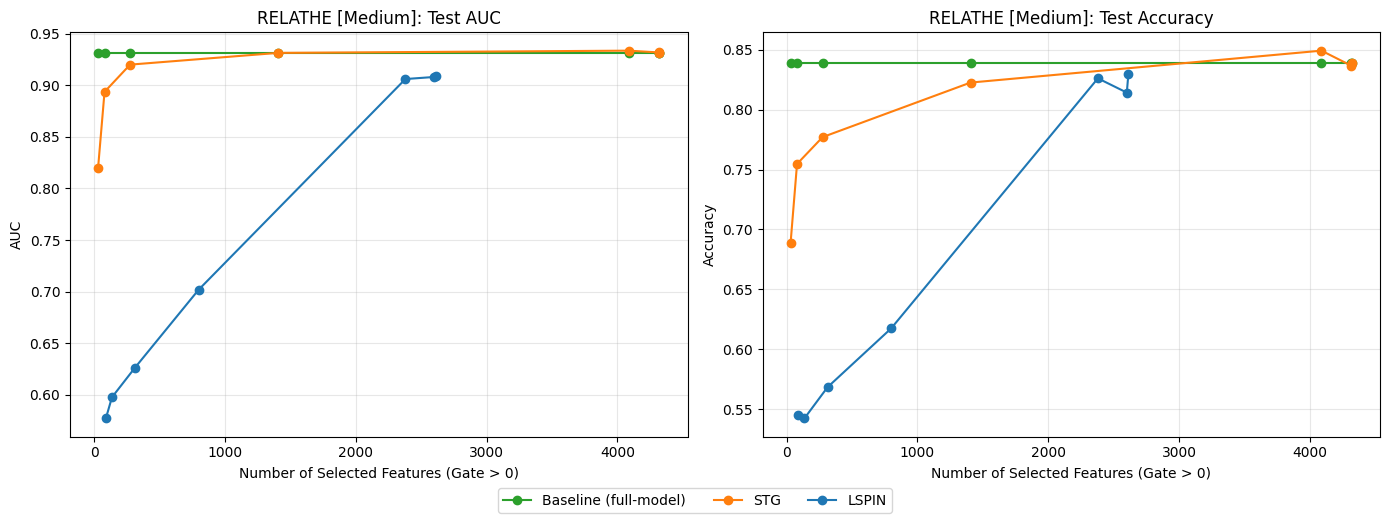

Saved train plot: g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\plots\RELATHE_train_curves_num_features.png


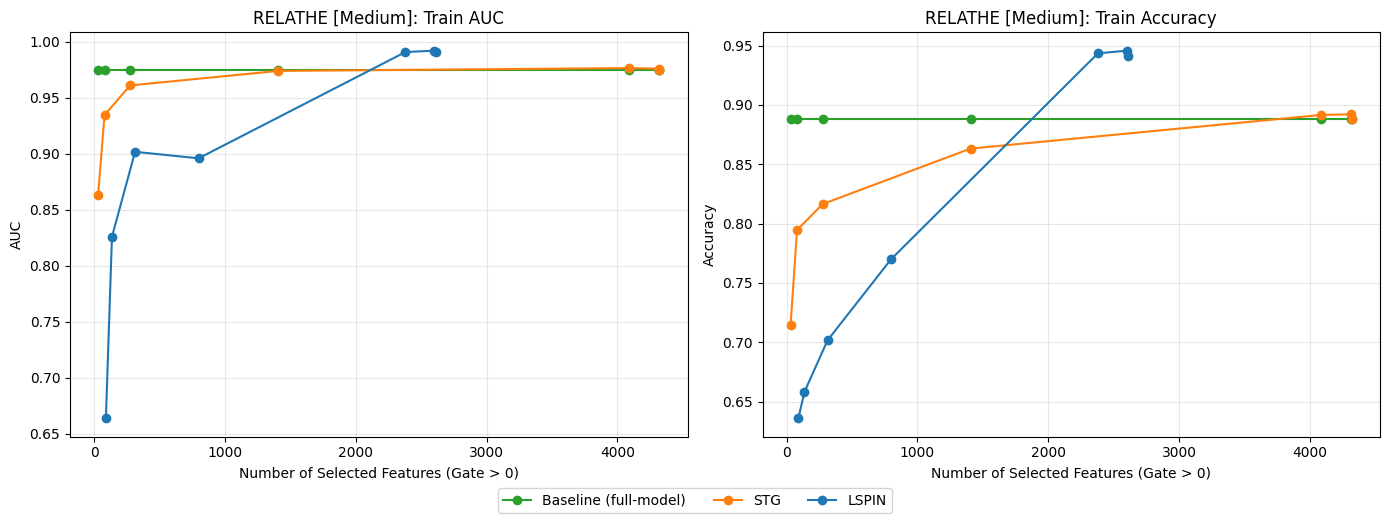

Saved loss plot: g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\plots\RELATHE_train_loss_curve_num_features.png


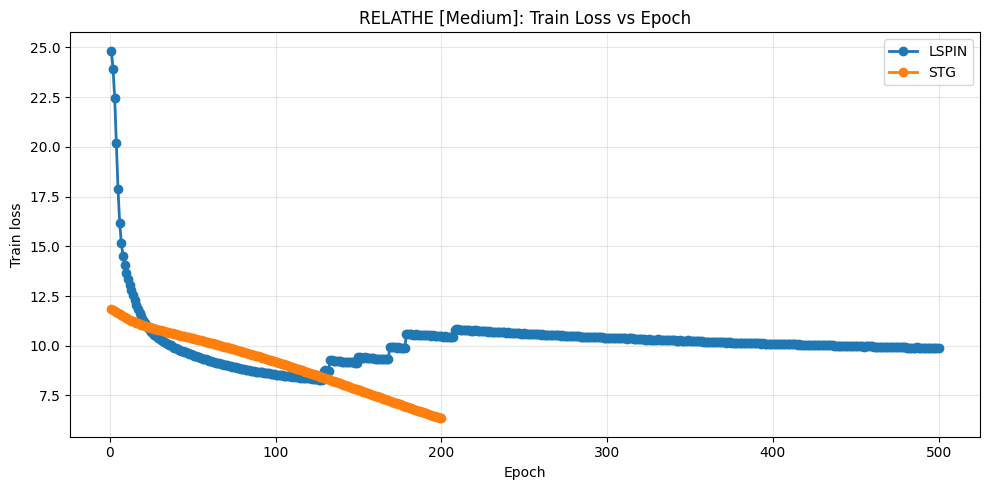

Saved lambda selected-features plot: g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\plots\RELATHE_lambda_selected_features_summary.png


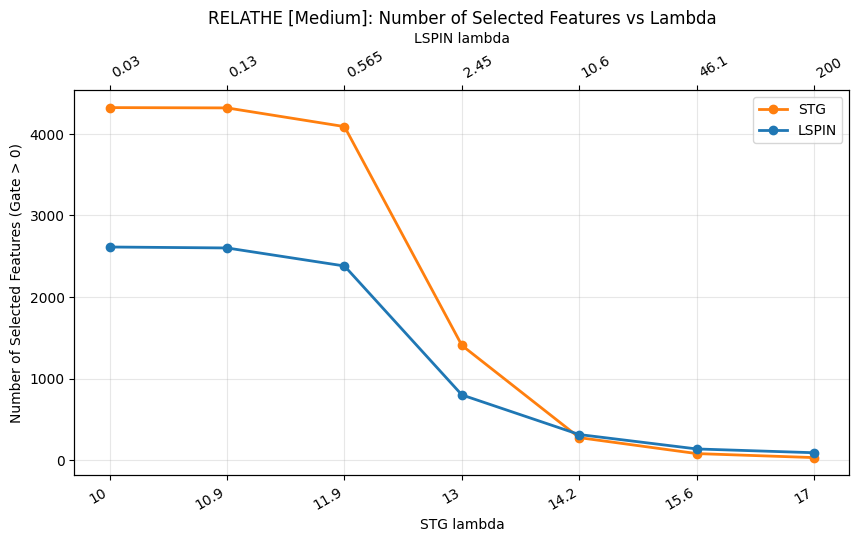

Saved test plot: g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\plots\madelon_test_curves_num_features.png


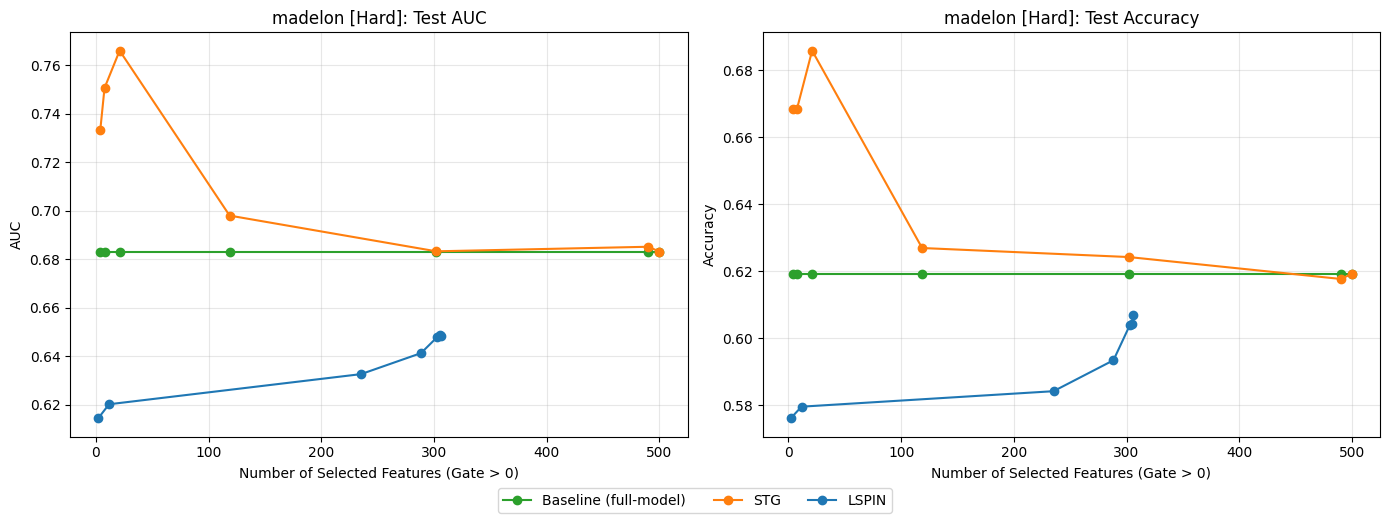

Saved train plot: g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\plots\madelon_train_curves_num_features.png


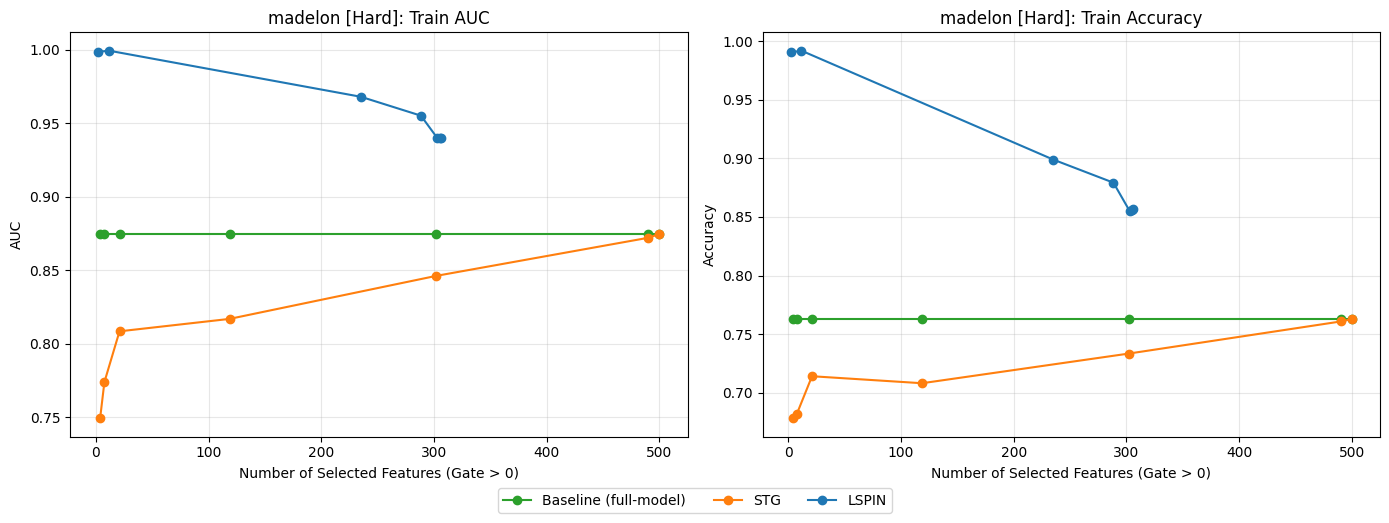

Saved loss plot: g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\plots\madelon_train_loss_curve_num_features.png


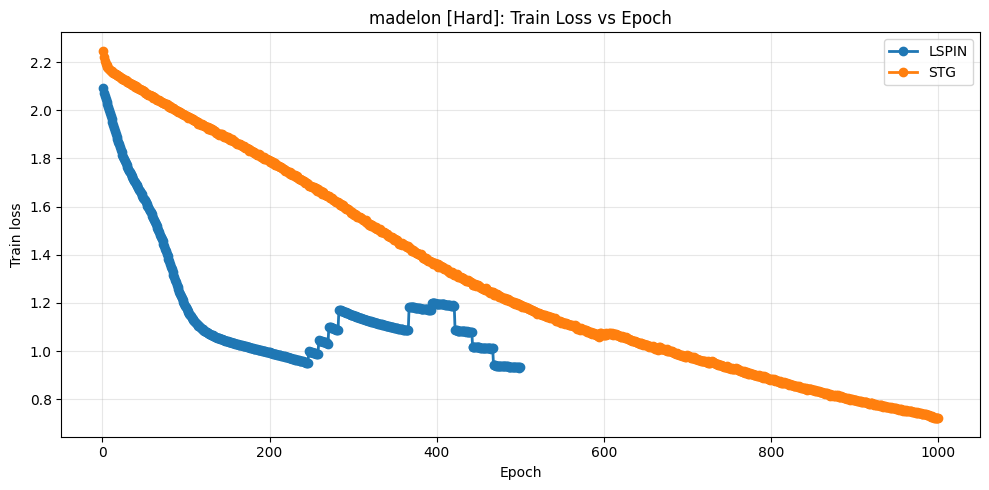

Saved lambda selected-features plot: g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\plots\madelon_lambda_selected_features_summary.png


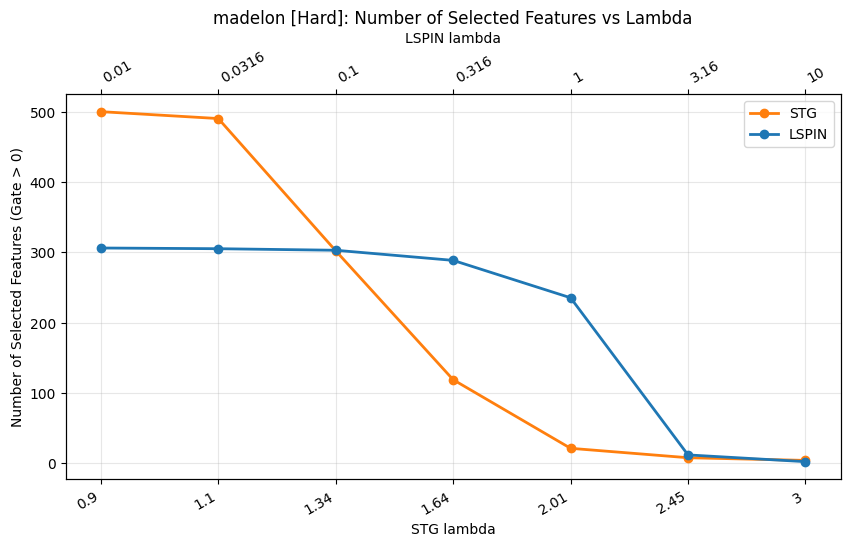

: 

In [ ]:
difficulty_by_dataset = {}
for idx, name in enumerate(DEFAULT_DATASET_NAMES):
    if idx < 1:
        difficulty_by_dataset[name] = "Hard"
    elif idx < 2:
        difficulty_by_dataset[name] = "Medium"
    else:
        difficulty_by_dataset[name] = "Easy"

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

current_method = combined_summary_df["feature_selection_method"].dropna().iloc[0] if not combined_summary_df.empty else "features_ratio"
if current_method == "features_ratio":
    sort_col = "feature_ratio"
    x_label = "Retained features ratio (k/p)"
    x_scale = "linear"
    suffix = "feature_ratio"
else:
    sort_col = "lambda_value"
    x_label = "Number of Selected Features (Gate > 0)"
    x_scale = "linear"
    suffix = "num_features"

for dataset_name in sorted(combined_summary_df["dataset"].unique()):
    part = combined_summary_df[combined_summary_df["dataset"] == dataset_name].copy()
    part = part[part["feature_selection_method"] == current_method].sort_values(sort_col)
    difficulty = difficulty_by_dataset.get(dataset_name, "Unknown")

    if part.empty:
        continue

    if current_method == "features_ratio":
        x_stg = part["feature_ratio"]
        x_lspin = part["feature_ratio"]
        x_base = part["feature_ratio"]
    else:
        x_stg = part["stg_selected_features_mean"]
        x_lspin = part["lspin_selected_features_mean"]
        x_base = part["stg_selected_features_mean"] 

    # Test-set curves
    fig_test, axes_test = plt.subplots(1, 2, figsize=(14, 5))

    axes_test[0].plot(x_base, part["baseline_auc_mean"], marker="o", color="tab:green", label="Baseline (full-model)")
    axes_test[0].plot(x_stg, part["stg_auc_mean"], marker="o", color="tab:orange", label="STG")
    axes_test[0].plot(x_lspin, part["lspin_auc_mean"], marker="o", color="tab:blue", label="LSPIN")
    axes_test[0].set_title(f"{dataset_name} [{difficulty}]: Test AUC")
    axes_test[0].set_xlabel(x_label)
    axes_test[0].set_ylabel("AUC")
    axes_test[0].set_xscale(x_scale)
    axes_test[0].grid(True, alpha=0.3)

    axes_test[1].plot(x_base, part["baseline_accuracy_mean"], marker="o", color="tab:green", label="Baseline (full-model)")
    axes_test[1].plot(x_stg, part["stg_accuracy_mean"], marker="o", color="tab:orange", label="STG")
    axes_test[1].plot(x_lspin, part["lspin_accuracy_mean"], marker="o", color="tab:blue", label="LSPIN")
    axes_test[1].set_title(f"{dataset_name} [{difficulty}]: Test Accuracy")
    axes_test[1].set_xlabel(x_label)
    axes_test[1].set_ylabel("Accuracy")
    axes_test[1].set_xscale(x_scale)
    axes_test[1].grid(True, alpha=0.3)

    handles_test, labels_test = axes_test[1].get_legend_handles_labels()
    fig_test.legend(handles_test, labels_test, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig_test.tight_layout()

    test_plot_path = plots_dir / f"{dataset_name}_test_curves_{suffix}.png"
    fig_test.savefig(test_plot_path, dpi=150, bbox_inches="tight")
    print(f"Saved test plot: {test_plot_path}")
    plt.show()

    # Train-set curves (only if present in summary columns)
    train_cols = {
        "baseline_train_auc_mean", "stg_train_auc_mean", "lspin_train_auc_mean",
        "baseline_train_accuracy_mean", "stg_train_accuracy_mean", "lspin_train_accuracy_mean",
    }
    if train_cols.issubset(part.columns):
        fig_train, axes_train = plt.subplots(1, 2, figsize=(14, 5))

        axes_train[0].plot(x_base, part["baseline_train_auc_mean"], marker="o", color="tab:green", label="Baseline (full-model)")
        axes_train[0].plot(x_stg, part["stg_train_auc_mean"], marker="o", color="tab:orange", label="STG")
        axes_train[0].plot(x_lspin, part["lspin_train_auc_mean"], marker="o", color="tab:blue", label="LSPIN")
        axes_train[0].set_title(f"{dataset_name} [{difficulty}]: Train AUC")
        axes_train[0].set_xlabel(x_label)
        axes_train[0].set_ylabel("AUC")
        axes_train[0].set_xscale(x_scale)
        axes_train[0].grid(True, alpha=0.3)

        axes_train[1].plot(x_base, part["baseline_train_accuracy_mean"], marker="o", color="tab:green", label="Baseline (full-model)")
        axes_train[1].plot(x_stg, part["stg_train_accuracy_mean"], marker="o", color="tab:orange", label="STG")
        axes_train[1].plot(x_lspin, part["lspin_train_accuracy_mean"], marker="o", color="tab:blue", label="LSPIN")
        axes_train[1].set_title(f"{dataset_name} [{difficulty}]: Train Accuracy")
        axes_train[1].set_xlabel(x_label)
        axes_train[1].set_ylabel("Accuracy")
        axes_train[1].set_xscale(x_scale)
        axes_train[1].grid(True, alpha=0.3)

        handles_train, labels_train = axes_train[1].get_legend_handles_labels()
        fig_train.legend(handles_train, labels_train, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
        fig_train.tight_layout()

        train_plot_path = plots_dir / f"{dataset_name}_train_curves_{suffix}.png"
        fig_train.savefig(train_plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved train plot: {train_plot_path}")
        plt.show()
    else:
        print(f"Train-summary columns are missing for {dataset_name}; skipped train plot.")

    loss_part = combined_loss_df[combined_loss_df["dataset"] == dataset_name].copy()
    loss_part = loss_part[loss_part["feature_selection_method"] == current_method]
    if not loss_part.empty:
        loss_summary = (
            loss_part.groupby(["algorithm", "epoch"], as_index=False)["train_loss"]
            .mean()
            .sort_values(["algorithm", "epoch"])
        )
        fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
        for algorithm_name, algo_part in loss_summary.groupby("algorithm"):
            color = "tab:orange" if algorithm_name == "STG" else "tab:blue"
            ax_loss.plot(
                algo_part["epoch"],
                algo_part["train_loss"],
                marker="o",
                linewidth=2,
                color=color,
                label=algorithm_name,
            )
        ax_loss.set_title(f"{dataset_name} [{difficulty}]: Train Loss vs Epoch")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Train loss")
        ax_loss.grid(True, alpha=0.3)
        ax_loss.legend()
        fig_loss.tight_layout()

        loss_plot_path = plots_dir / f"{dataset_name}_train_loss_curve_{suffix}.png"
        fig_loss.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved loss plot: {loss_plot_path}")
        plt.show()
    else:
        print(f"Loss history is missing for {dataset_name}; skipped loss plot.")

    if current_method == "lamda_tuning" and {
        "stg_selected_features_mean", "lspin_selected_features_mean", "lambda_value"
    }.issubset(part.columns):
        x_positions = np.arange(len(part))
        stg_labels = [f"{v:.3g}" for v in part["lambda_value"].to_numpy()]
        lspin_labels = [f"{v:.3g}" for v in part.get("lspin_lambda_value", part["lambda_value"]).to_numpy()]

        fig_sel, ax_sel = plt.subplots(figsize=(10, 5))
        ax_sel.plot(x_positions, part["stg_selected_features_mean"], marker="o", linewidth=2, color="tab:orange", label="STG")
        ax_sel.plot(x_positions, part["lspin_selected_features_mean"], marker="o", linewidth=2, color="tab:blue", label="LSPIN")
        ax_sel.set_title(f"{dataset_name} [{difficulty}]: Number of Selected Features vs Lambda")
        ax_sel.set_xlabel("STG lambda")
        ax_sel.set_ylabel("Number of Selected Features (Gate > 0)")
        ax_sel.set_xticks(x_positions)
        ax_sel.set_xticklabels(stg_labels, rotation=30, ha="right")
        ax_sel.grid(True, alpha=0.3)
        ax_sel.legend()

        ax_sel_top = ax_sel.twiny()
        ax_sel_top.set_xlim(ax_sel.get_xlim())
        ax_sel_top.set_xticks(x_positions)
        ax_sel_top.set_xticklabels(lspin_labels, rotation=30, ha="left")
        ax_sel_top.set_xlabel("LSPIN lambda")

        sel_plot_path = plots_dir / f"{dataset_name}_lambda_selected_features_summary.png"
        fig_sel.savefig(sel_plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved lambda selected-features plot: {sel_plot_path}")
        plt.show()

## Write Outputs to Separate Files

All outputs are written to the output folder. The source ETree file is never modified.

In [ ]:
summary_csv = OUTPUT_DIR / "iterative_feature_curve_summary.csv"
fold_csv = OUTPUT_DIR / "iterative_feature_curve_fold_results.csv"
loss_csv = OUTPUT_DIR / "iterative_feature_curve_loss_history.csv"

combined_summary_df.to_csv(summary_csv, index=False)
combined_fold_df.to_csv(fold_csv, index=False)
combined_loss_df.to_csv(loss_csv, index=False)

print("Saved:")
print("-", summary_csv)
print("-", fold_csv)
print("-", loss_csv)

Saved:
- g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\iterative_feature_curve_summary.csv
- g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\iterative_feature_curve_fold_results.csv
- g:\My Drive\Colab Notebooks\Thesis\output\2026-04-21_10-15-47\iterative_feature_curve_loss_history.csv


: 

## Repeatable Execution Checks

Run this cell anytime to quickly re-check output artifacts without rerunning model training.

In [ ]:
import shutil


checks = {
    "summary_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_summary.csv").exists(),
    "fold_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_fold_results.csv").exists(),
    "loss_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_loss_history.csv").exists(),
}

check_df = pd.DataFrame([checks])
display(check_df)

# if not all(checks.values()):
#     raise RuntimeError("One or more repeatability checks failed.")

print("All repeatability checks passed.")
import inspect
if IN_COLAB:
    # Get the file name of the current frame (the notebook)
    filepath = Path(os.path.basename(__vsc_ipynb_file__))
    print(f"Running in a notebook environment. Detected notebook file: {filepath}")
# handle this kind of path: "g:\האחסון שלי\Colab Notebooks\Thesis\main2.ipynb"
    filename = os.path.basename(filepath).split("\\")[-1]
    filepath = Path("/content/drive/MyDrive/Colab Notebooks/Thesis")
else:
    filepath = BASE_DIR
    filename = Path(os.path.basename(__vsc_ipynb_file__))
    
    print(f"Running in a script environment. Detected file: {filename} in directory: {filepath}")


#check if filepath correct(the notebokk is in there)
notebook_files = os.listdir(filepath)
print(f"Files in notebook directory: {notebook_files}")
print(f"Looking for notebook file: {filename}")
# if filename not in notebook_files:
#     raise RuntimeError(f"Notebook file '{filename}' not found in the notebook directory '{filepath}'. Found files: {notebook_files}")
shutil.copy2(os.path.join(filepath, filename), OUTPUT_DIR)
print(f"Copied notebook to output directory: {os.path.join(OUTPUT_DIR, filename)}")

,summary_csv_exists,fold_csv_exists,loss_csv_exists
0,False,False,False


All repeatability checks passed.
Running in a script environment. Detected file: main2.ipynb in directory: g:\האחסון שלי\Colab Notebooks\Thesis
Files in notebook directory: ['.tmp.driveupload', 'data', 'FeatureSelect-Benchmark-Hub', 'main.ipynb', 'output', '.git', 'main2.ipynb']
Looking for notebook file: main2.ipynb


RuntimeError: Notebook file 'main2.ipynb' not found in the notebook directory 'g:\האחסון שלי\Colab Notebooks\Thesis'. Found files: ['.tmp.driveupload', 'data', 'FeatureSelect-Benchmark-Hub', 'main.ipynb', 'output', '.git', 'main2.ipynb']

: 